# Trabalho 03 — Redimensionamento de Resolução (PGM Tons de Cinza — P2)

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Objetivo

A partir da imagem de referência `Entrada_EscalaCinza.pgm` (formato **PGM tipo
P2**, ASCII), gerar versões redimensionadas nas seguintes resoluções:

| Item | Resolução alvo   | Observação                          |
|------|------------------|--------------------------------------|
| (a)  | 10× menor        | 800×800 → 80×80                      |
| (b)  | 480×320          | padrão                               |
| (c)  | 1280×720 (HD)    | padrão                               |
| (d)  | 1920×1080 (Full HD) | padrão                            |
| (e)  | 3840×2160 (4K) e 7680×4320 (8K) | ampliação, interpolada |

O enunciado não exige um método específico de reamostragem — a escolha do
algoritmo é livre. Uso dois métodos:

- **Vizinho mais próximo (nearest neighbor)** — o mais simples, útil como
  referência de comparação.
- **Interpolação bilinear** — usada nos itens que pedem explicitamente
  "interpolada" e, por qualidade, também nos demais aumentos de resolução.

Para a redução 10× menor (item a), comparo o vizinho mais próximo com a
**média de bloco** (box downsampling), que evita aliasing por não descartar
informação — cada pixel de saída é a média do bloco 10×10 correspondente.

### Observação sobre proporção

A imagem de entrada é quadrada (800×800, proporção 1:1). Nenhuma das
resoluções-alvo mantém essa proporção (480×320 é 3:2, 720p/1080p/4K/8K são
16:9). Como o enunciado não pede preservação de aspecto nem cortes/bordas,
redimensiono diretamente para as dimensões alvo (esticando os eixos de forma
independente), o que é a interpretação mais direta de "redimensionar
resolução".


In [1]:
# Bibliotecas e configurações globais

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ENTRADA = Path("data/Entrada_EscalaCinza.pgm")
SAIDA = Path("saida")
SAIDA.mkdir(exist_ok=True)

LIMITE_COLUNA = 70

print(f"Numpy    : {np.__version__}")
print(f"Entrada  : {ENTRADA.resolve()}")
print(f"Saída    : {SAIDA.resolve()}")


Numpy    : 2.5.2
Entrada  : /home/igorkg/PycharmProjects/TrabalhoRGBProcessamentoDigitalDeImagem/data/Entrada_EscalaCinza.pgm
Saída    : /home/igorkg/PycharmProjects/TrabalhoRGBProcessamentoDigitalDeImagem/saida


## 1. Leitura e escrita do formato P2

Mesmo esquema da Tarefa 02: um parser baseado em fluxo de tokens (tolerante a
espaços, quebras de linha e comentários `#`) e um escritor que respeita o
limite de 70 caracteres por linha, calculando o número de valores por linha
pelo pior caso (maior token possível) e escrevendo em blocos para não
estourar memória nas imagens grandes (8K tem ~33 milhões de pixels).


In [2]:
def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pgm_p2(caminho):
    """Lê um arquivo PGM tipo P2 completo e devolve (matriz uint8/int, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)
        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado P2)")
        largura, altura, maxval = (int(next(it)) for _ in range(3))
        total = largura * altura
        valores = np.fromiter((int(next(it)) for _ in range(total)), dtype=np.int32, count=total)

    return valores.reshape(altura, largura), maxval


def calcular_valores_por_linha(maxval, limite_coluna=LIMITE_COLUNA):
    """Quantos valores cabem por linha sem violar o limite de colunas (pior caso)."""
    largura_token = len(str(maxval))
    n = (limite_coluna + 1) // (largura_token + 1)
    return max(1, n)


def escrever_pgm_p2(caminho, pixels, maxval, comentario=None,
                     limite_coluna=LIMITE_COLUNA, pixels_por_bloco=200_000):
    """Grava um array (altura, largura) como arquivo PGM tipo P2 (ASCII)."""
    pixels = np.asarray(pixels)
    if pixels.ndim != 2:
        raise ValueError(f"Esperado shape (altura, largura), recebeu {pixels.shape}")
    if pixels.min() < 0 or pixels.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura = pixels.shape
    n = calcular_valores_por_linha(maxval, limite_coluna)
    plano = pixels.reshape(-1)

    # bloco de escrita múltiplo de n, para nunca quebrar uma linha ao meio
    bloco = max(n, (pixels_por_bloco // n) * n)

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P2\n")
        if comentario:
            f.write(f"# {comentario}\n")
        f.write(f"{largura} {altura}\n{maxval}\n")

        for inicio in range(0, plano.size, bloco):
            fatia = plano[inicio:inicio + bloco].tolist()
            linhas = [
                " ".join(map(str, fatia[i:i + n]))
                for i in range(0, len(fatia), n)
            ]
            f.write("\n".join(linhas))
            f.write("\n")


# Verificação rápida: ler a entrada e conferir cabeçalho
imagem_entrada, maxval_entrada = ler_pgm_p2(ENTRADA)
print(f"Dimensões : {imagem_entrada.shape[1]}x{imagem_entrada.shape[0]}")
print(f"maxval    : {maxval_entrada}")
print(f"min / max : {imagem_entrada.min()} / {imagem_entrada.max()}")


Dimensões : 800x800
maxval    : 255
min / max : 13 / 243


## 2. Algoritmos de redimensionamento

Três métodos, todos implementados diretamente sobre a matriz 2D (escala de
cinza, sem canais de cor):

- **Vizinho mais próximo** — para cada pixel de saída, mapeia de volta para a
  coordenada mais próxima na imagem de entrada. Rápido, mas introduz
  serrilhado (aliasing), especialmente ao ampliar.
- **Bilinear** — interpola linearmente nos dois eixos a partir dos 4 vizinhos
  mais próximos. Implementado de forma separável (1D no eixo das colunas,
  depois 1D no eixo das linhas) para eficiência.
- **Média de bloco (box downsampling)** — usada apenas na redução exata 10×.
  Cada pixel de saída é a média do bloco correspondente na entrada; evita
  descartar informação (o problema do vizinho mais próximo ao reduzir).


In [3]:
def redimensionar_vizinho_mais_proximo(imagem, nova_largura, nova_altura):
    altura, largura = imagem.shape
    linhas_idx = (np.arange(nova_altura) * altura / nova_altura).astype(np.int32)
    colunas_idx = (np.arange(nova_largura) * largura / nova_largura).astype(np.int32)
    linhas_idx = np.clip(linhas_idx, 0, altura - 1)
    colunas_idx = np.clip(colunas_idx, 0, largura - 1)
    return imagem[linhas_idx[:, None], colunas_idx[None, :]]


def _interpolar_eixo_1d(imagem, novo_tamanho, eixo):
    """Interpolação bilinear em um único eixo (usada duas vezes p/ separabilidade)."""
    tamanho_original = imagem.shape[eixo]
    if tamanho_original == 1:
        indices = np.zeros(novo_tamanho, dtype=np.float64)
    else:
        escala = tamanho_original / novo_tamanho
        indices = (np.arange(novo_tamanho) + 0.5) * escala - 0.5
        indices = np.clip(indices, 0, tamanho_original - 1)

    idx0 = np.floor(indices).astype(np.int32)
    idx1 = np.clip(idx0 + 1, 0, tamanho_original - 1)
    peso1 = (indices - idx0).astype(np.float64)
    peso0 = 1.0 - peso1

    imagem = imagem.astype(np.float64)
    if eixo == 0:
        return imagem[idx0, :] * peso0[:, None] + imagem[idx1, :] * peso1[:, None]
    else:
        return imagem[:, idx0] * peso0[None, :] + imagem[:, idx1] * peso1[None, :]


def redimensionar_bilinear(imagem, nova_largura, nova_altura):
    intermediaria = _interpolar_eixo_1d(imagem, nova_largura, eixo=1)
    final = _interpolar_eixo_1d(intermediaria, nova_altura, eixo=0)
    return final


def redimensionar_media_bloco(imagem, fator):
    """Reduz por um fator inteiro exato, tirando a média de cada bloco fator x fator."""
    altura, largura = imagem.shape
    if altura % fator or largura % fator:
        raise ValueError("Fator de redução deve dividir exatamente as dimensões")
    nova_altura, nova_largura = altura // fator, largura // fator
    blocos = imagem.reshape(nova_altura, fator, nova_largura, fator)
    return blocos.mean(axis=(1, 3))


def para_uint8(imagem, maxval=255):
    return np.clip(np.round(imagem), 0, maxval).astype(np.uint8)


## 3. Item (a) — 10× menor (800×800 → 80×80)

O fator 10 divide exatamente as dimensões da entrada, então uso a **média de
bloco** como resultado principal (menos aliasing) e gero também a versão por
**vizinho mais próximo** só para comparação visual — ambas salvas em arquivo.


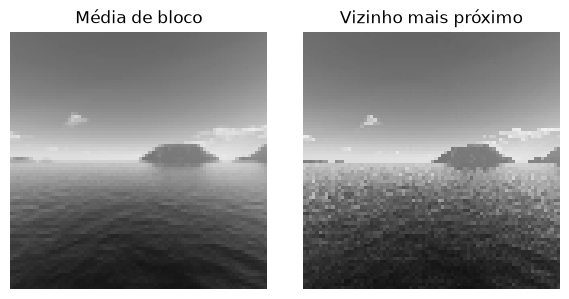

Salvo: saida/a_80x80_10x_menor_media.pgm (23608 bytes)
Salvo: saida/a_80x80_10x_menor_vizinho.pgm (23653 bytes)


In [4]:
FATOR_A = 10
LARGURA_A, ALTURA_A = 800 // FATOR_A, 800 // FATOR_A

img_a_media = para_uint8(redimensionar_media_bloco(imagem_entrada, FATOR_A), maxval_entrada)
img_a_vizinho = para_uint8(
    redimensionar_vizinho_mais_proximo(imagem_entrada, LARGURA_A, ALTURA_A), maxval_entrada
)

ARQUIVO_A = SAIDA / "a_80x80_10x_menor_media.pgm"
ARQUIVO_A_VIZINHO = SAIDA / "a_80x80_10x_menor_vizinho.pgm"
escrever_pgm_p2(ARQUIVO_A, img_a_media, maxval_entrada,
                comentario="Item (a): 10x menor, media de bloco")
escrever_pgm_p2(ARQUIVO_A_VIZINHO, img_a_vizinho, maxval_entrada,
                comentario="Item (a): 10x menor, vizinho mais proximo (comparacao)")

fig, eixos = plt.subplots(1, 2, figsize=(6, 3))
eixos[0].imshow(img_a_media, cmap="gray", vmin=0, vmax=maxval_entrada)
eixos[0].set_title("Média de bloco")
eixos[1].imshow(img_a_vizinho, cmap="gray", vmin=0, vmax=maxval_entrada)
eixos[1].set_title("Vizinho mais próximo")
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()
plt.show()

print(f"Salvo: {ARQUIVO_A} ({ARQUIVO_A.stat().st_size} bytes)")
print(f"Salvo: {ARQUIVO_A_VIZINHO} ({ARQUIVO_A_VIZINHO.stat().st_size} bytes)")


## 4. Itens (b)-(d) — Padrões 480×320, 720p e 1080p

Todos são reduções (a entrada é 800×800). Uso interpolação bilinear, que
produz resultado mais suave que o vizinho mais próximo nessas escalas não
inteiras.


Salvo: saida/b_480x320.pgm (565148 bytes) — 480x320
Salvo: saida/c_1280x720_HD.pgm (3390425 bytes) — 1280x720


Salvo: saida/d_1920x1080_FullHD.pgm (7628498 bytes) — 1920x1080


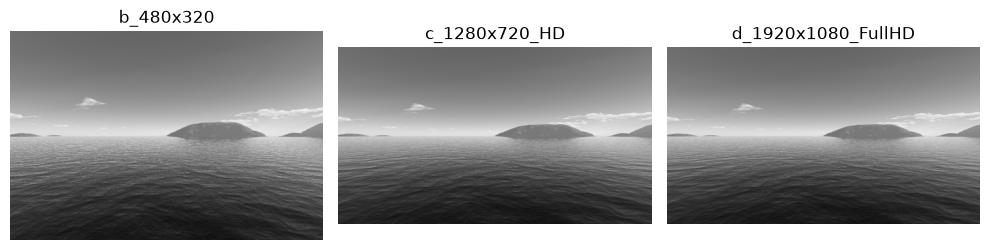

In [5]:
RESOLUCOES_BCD = [
    ("b_480x320", 480, 320),
    ("c_1280x720_HD", 1280, 720),
    ("d_1920x1080_FullHD", 1920, 1080),
]

resultados_bcd = {}
for nome, largura, altura in RESOLUCOES_BCD:
    imagem_redim = para_uint8(
        redimensionar_bilinear(imagem_entrada, largura, altura), maxval_entrada
    )
    caminho = SAIDA / f"{nome}.pgm"
    escrever_pgm_p2(caminho, imagem_redim, maxval_entrada,
                     comentario=f"{largura}x{altura}, bilinear")
    resultados_bcd[nome] = (caminho, imagem_redim)
    print(f"Salvo: {caminho} ({caminho.stat().st_size} bytes) — {largura}x{altura}")

fig, eixos = plt.subplots(1, 3, figsize=(10, 4))
for eixo, (nome, (caminho, imagem_redim)) in zip(eixos, resultados_bcd.items()):
    eixo.imshow(imagem_redim, cmap="gray", vmin=0, vmax=maxval_entrada)
    eixo.set_title(nome)
    eixo.axis("off")
plt.tight_layout()
plt.show()


## 5. Item (e) — 4K e 8K (ampliação interpolada)

Aqui a imagem é **ampliada** (800×800 → 3840×2160 / 7680×4320), então a
escolha do método afeta diretamente a suavidade do resultado. Uso bilinear,
como pedido ("interpolada"). O 8K gera ~33 milhões de pixels; a escrita em
blocos evita estourar memória.


In [6]:
GERAR_8K = True  # pode desligar se disco/tempo forem restritivos

RESOLUCOES_E = [("e_3840x2160_4K", 3840, 2160)]
if GERAR_8K:
    RESOLUCOES_E.append(("e_7680x4320_8K", 7680, 4320))

resultados_e = {}
for nome, largura, altura in RESOLUCOES_E:
    imagem_redim = para_uint8(
        redimensionar_bilinear(imagem_entrada, largura, altura), maxval_entrada
    )
    caminho = SAIDA / f"{nome}.pgm"
    escrever_pgm_p2(caminho, imagem_redim, maxval_entrada,
                     comentario=f"{largura}x{altura}, bilinear (ampliacao)")
    resultados_e[nome] = (caminho, imagem_redim)
    print(f"Salvo: {caminho} ({caminho.stat().st_size / 1e6:.1f} MB) — {largura}x{altura}")


Salvo: saida/e_3840x2160_4K.pgm (30.5 MB) — 3840x2160


Salvo: saida/e_7680x4320_8K.pgm (122.1 MB) — 7680x4320


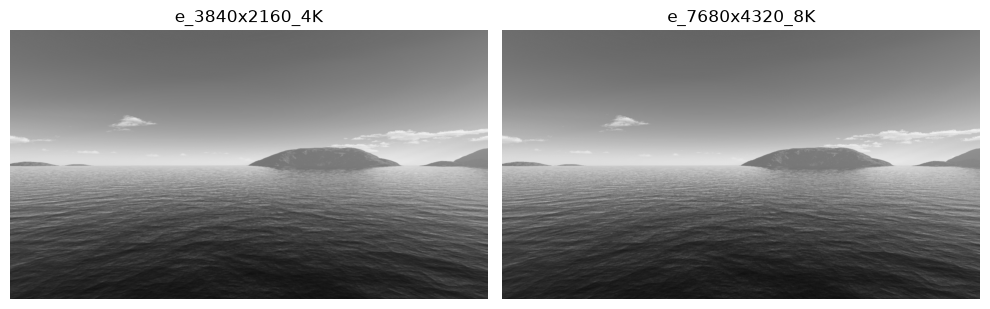

In [7]:
fig, eixos = plt.subplots(1, len(resultados_e), figsize=(5 * len(resultados_e), 5))
if len(resultados_e) == 1:
    eixos = [eixos]
for eixo, (nome, (caminho, imagem_redim)) in zip(eixos, resultados_e.items()):
    eixo.imshow(imagem_redim, cmap="gray", vmin=0, vmax=maxval_entrada)
    eixo.set_title(nome)
    eixo.axis("off")
plt.tight_layout()
plt.show()


## 6. Resumo e validação

Confere que cada arquivo gerado tem as dimensões esperadas, relendo o
cabeçalho com o parser da seção 1.


In [8]:
def ler_cabecalho_pgm(caminho):
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)
        magic = next(it)
        largura, altura, maxval = (int(next(it)) for _ in range(3))
    return {"magic": magic, "largura": largura, "altura": altura, "maxval": maxval}


todos_arquivos = (
    [(ARQUIVO_A, "80x80 (media bloco)"), (ARQUIVO_A_VIZINHO, "80x80 (vizinho)")]
    + [(caminho, nome) for nome, (caminho, _) in resultados_bcd.items()]
    + [(caminho, nome) for nome, (caminho, _) in resultados_e.items()]
)

cabecalho = f"{'Arquivo':<38}{'Dimensões':>12}{'Tamanho':>12}"
print(cabecalho)
print("-" * len(cabecalho))
for caminho, descricao in todos_arquivos:
    info = ler_cabecalho_pgm(caminho)
    dims = f"{info['largura']}x{info['altura']}"
    tamanho = caminho.stat().st_size
    unidade = "MB" if tamanho > 1e6 else "KB"
    valor = tamanho / 1e6 if unidade == "MB" else tamanho / 1e3
    print(f"{caminho.name:<38}{dims:>12}{f'{valor:.1f} {unidade}':>12}")
    assert info["magic"] == "P2"
    assert info["maxval"] == maxval_entrada

print("\nTodos os arquivos validados com sucesso.")


Arquivo                                  Dimensões     Tamanho
--------------------------------------------------------------
a_80x80_10x_menor_media.pgm                  80x80     23.6 KB
a_80x80_10x_menor_vizinho.pgm                80x80     23.7 KB
b_480x320.pgm                              480x320    565.1 KB
c_1280x720_HD.pgm                         1280x720      3.4 MB
d_1920x1080_FullHD.pgm                   1920x1080      7.6 MB
e_3840x2160_4K.pgm                       3840x2160     30.5 MB
e_7680x4320_8K.pgm                       7680x4320    122.1 MB

Todos os arquivos validados com sucesso.
